# Loan Approval Prediction

## 1. Loading the Data

In [2]:
import pandas as pd
import numpy as np

In [3]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [9]:
train_df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [10]:
test_df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,30,female,Associate,81739,5,RENT,20000,HOMEIMPROVEMENT,13.34,0.24,10,587,Yes,0
1,24,male,High School,39534,4,OWN,3514,MEDICAL,14.19,0.09,3,626,Yes,0
2,24,male,Associate,90974,1,RENT,1990,VENTURE,9.93,0.02,3,593,Yes,0
3,26,male,Associate,58893,2,MORTGAGE,10000,PERSONAL,8.97,0.17,4,629,No,0
4,38,male,High School,53790,16,MORTGAGE,8000,MEDICAL,9.80,0.15,12,590,Yes,0


# 2. EDA

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35999 entries, 0 to 35998
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      35999 non-null  int64  
 1   person_gender                   35999 non-null  object 
 2   person_education                35999 non-null  object 
 3   person_income                   35999 non-null  int64  
 4   person_emp_exp                  35999 non-null  int64  
 5   person_home_ownership           35999 non-null  object 
 6   loan_amnt                       35999 non-null  int64  
 7   loan_intent                     35999 non-null  object 
 8   loan_int_rate                   35999 non-null  float64
 9   loan_percent_income             35999 non-null  float64
 10  cb_person_cred_hist_length      35999 non-null  int64  
 11  credit_score                    35999 non-null  int64  
 12  previous_loan_defaults_on_file  

In [8]:
train_df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,35999.000000,3.599900e+04,35999.000000,35999.000000,35999.000000,35999.000000,35999.000000,35999.000000,35999.00000
mean,27.756104,8.078450e+04,5.492708,9547.586572,10.962231,0.137667,5.836412,632.813995,0.19745
std,6.257207,7.377958e+04,6.261994,6285.654364,3.021927,0.085669,4.007652,50.456070,0.39808
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.00000
25%,23.000000,4.787750e+04,1.000000,5000.000000,8.490000,0.070000,3.000000,602.000000,0.00000
50%,26.000000,6.754500e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.00000
75%,30.000000,9.682450e+04,8.000000,12000.000000,12.990000,0.190000,8.000000,670.000000,0.00000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.00000


### Checking for `Null`, `NaN`, `Duplicate`, `Outliers`

In [12]:
train_df.isna().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [13]:
test_df.isna().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

#### No Missing values found 

In [14]:
train_df.duplicated().sum()

np.int64(0)

In [15]:
test_df.duplicated().sum()

np.int64(0)

#### No duplicated values found 

In [18]:
train_df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [17]:
test_df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

#### No NULL values found 

## Checking for Outliers 

In [21]:
num_cols = train_df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = train_df[(train_df[col] < lower) | (train_df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

person_age: 1601 outliers
person_income: 1656 outliers
person_emp_exp: 1533 outliers
loan_amnt: 1902 outliers
loan_int_rate: 93 outliers
loan_percent_income: 542 outliers
cb_person_cred_hist_length: 1219 outliers
credit_score: 410 outliers
loan_status: 7108 outliers


In [22]:
num_cols = train_df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    Q1 = test_df[col].quantile(0.25)
    Q3 = test_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = test_df[(test_df[col] < lower) | (test_df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

person_age: 290 outliers
person_income: 474 outliers
person_emp_exp: 320 outliers
loan_amnt: 340 outliers
loan_int_rate: 34 outliers
loan_percent_income: 155 outliers
cb_person_cred_hist_length: 234 outliers
credit_score: 92 outliers
loan_status: 0 outliers


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

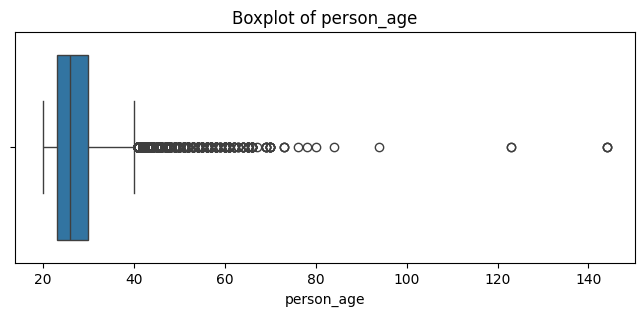

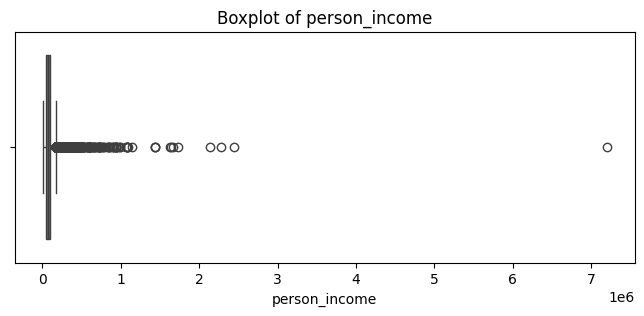

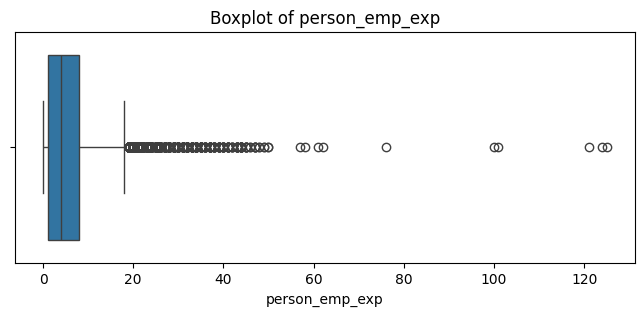

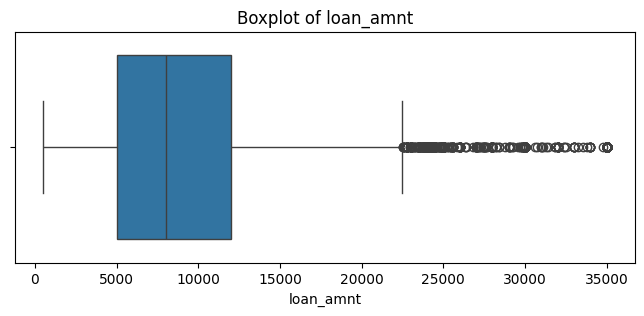

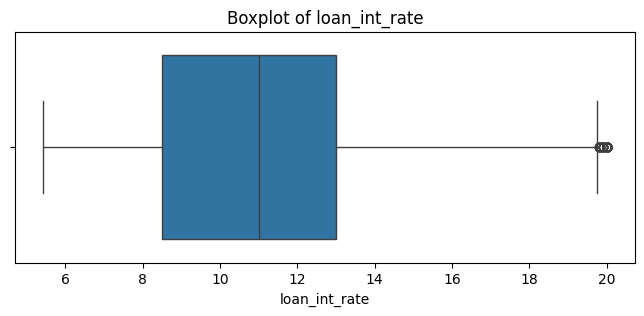

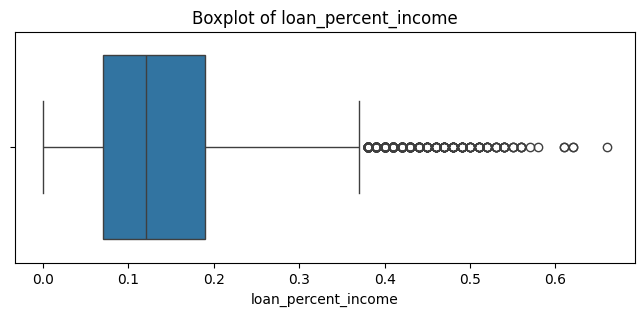

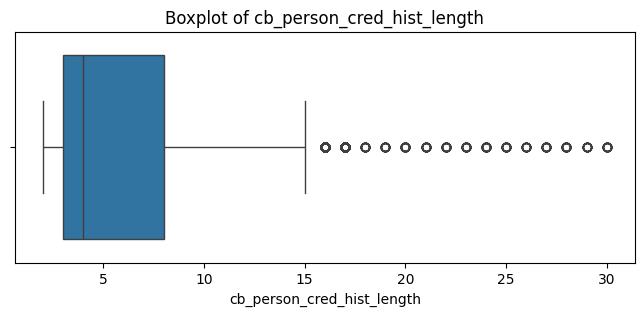

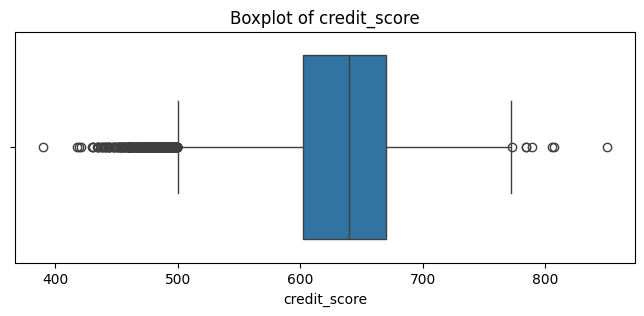

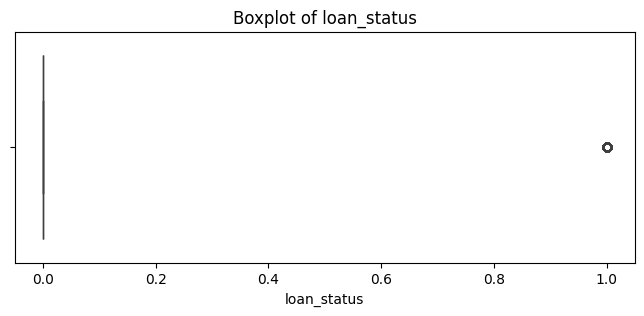

In [28]:
num_cols = train_df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=train_df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

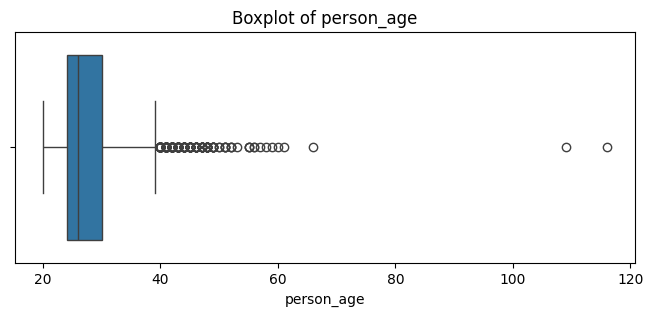

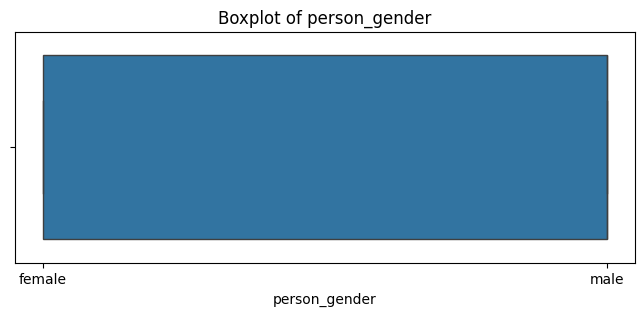

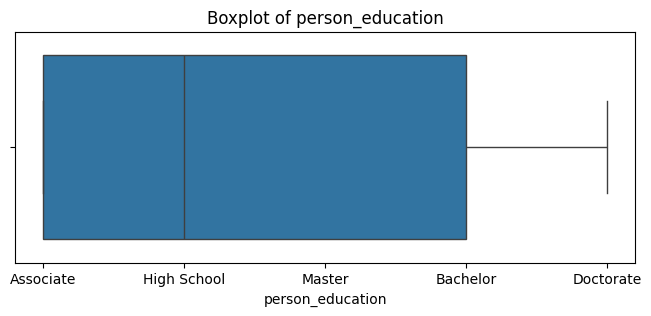

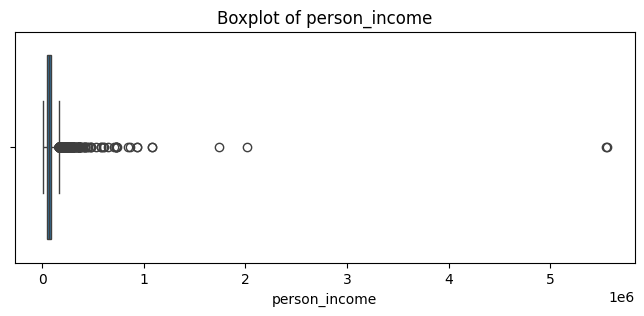

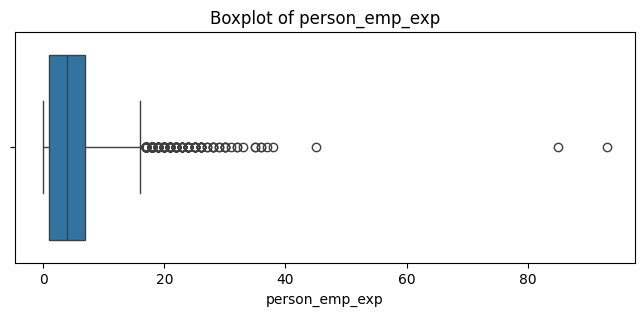

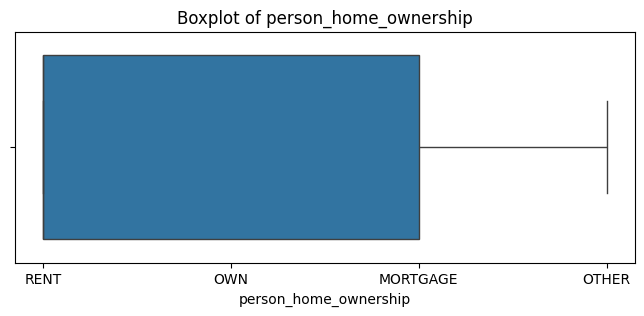

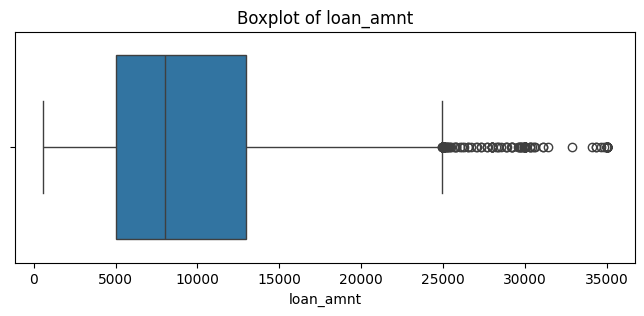

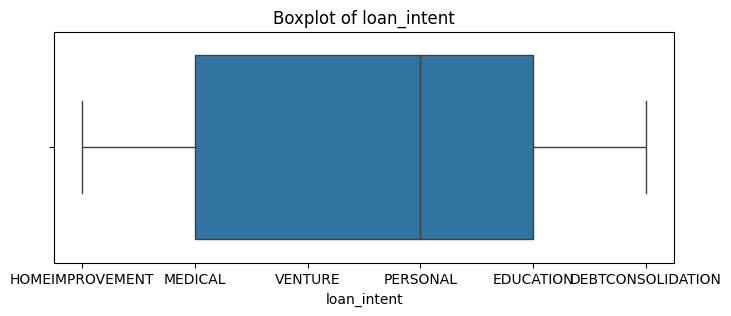

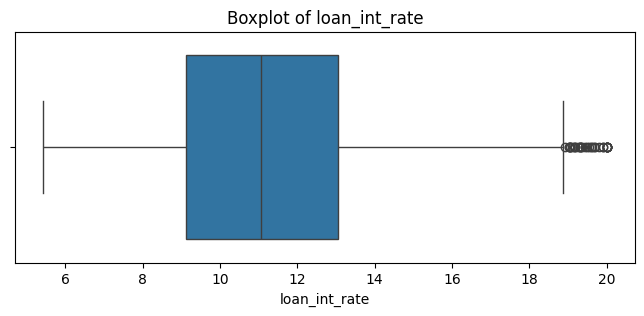

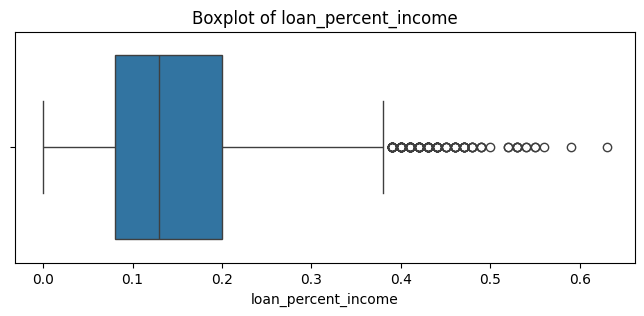

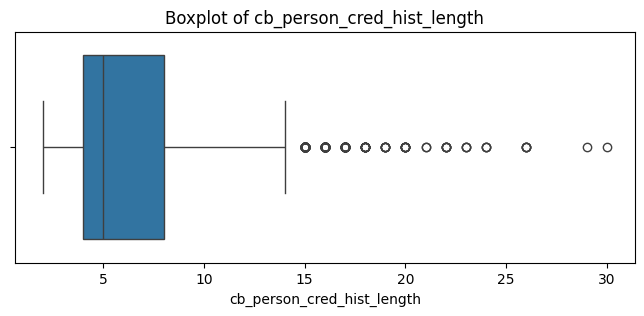

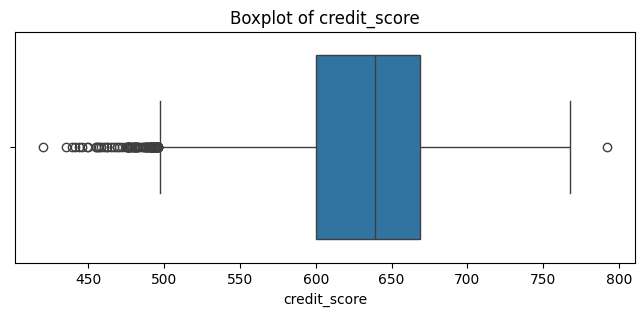

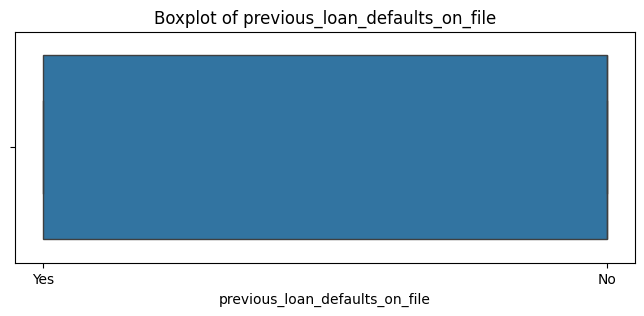

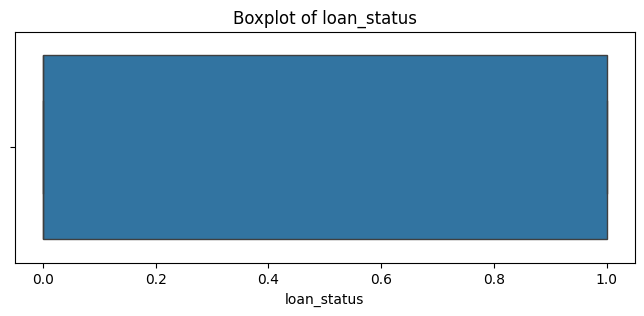

In [30]:
num_cols = test_df.select_dtypes(include=['int64','float64']).columns

for col in test_df:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=test_df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

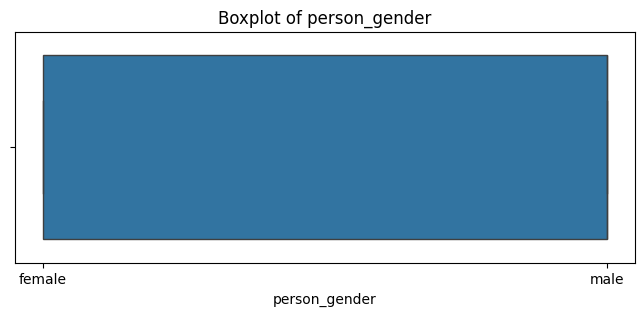

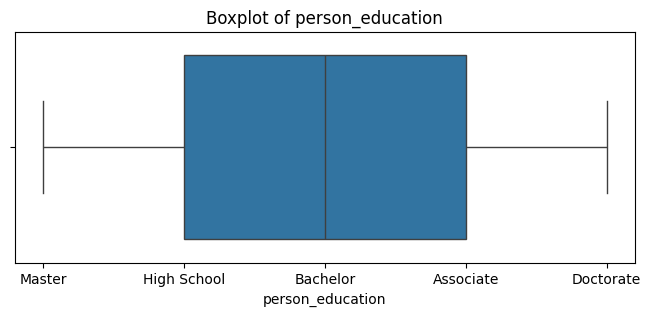

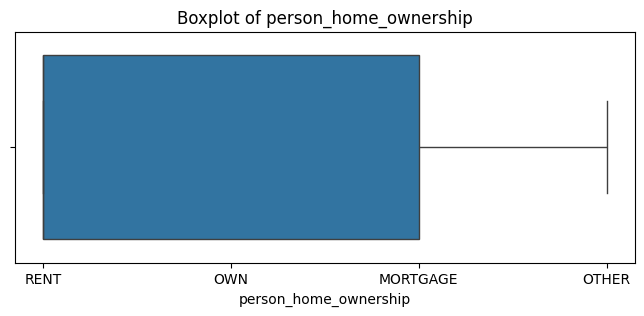

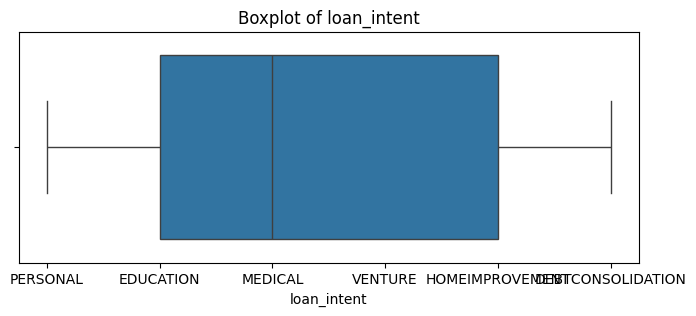

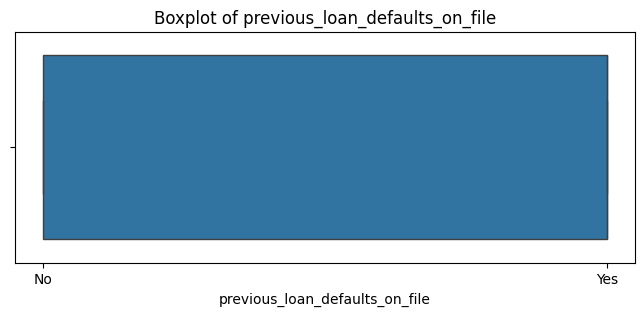

In [31]:
num_cols = train_df.select_dtypes(exclude=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=train_df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

## Outlier analysis revealed extreme values in applicant age. Since such values are likely due to data entry issues rather than genuine applicants, age outliers were treated using capping/removal. Income and loan amount outliers were retained because they may represent legitimate high-value customers and are important for risk assessment.

# 3. Segrgation 

In [48]:
X_train = train_df.iloc[:, :-1]
y_train = train_df.iloc[:, -1]

In [49]:
X_test= test_df.iloc[:, :-1]
y_test = test_df.iloc[:, -1]

## 4. No need for `test_train_split` bcoz at was given already

## 5. Train Data Preprocessing 

In [54]:
X_train

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35994,32,male,Bachelor,205076,8,MORTGAGE,10000,PERSONAL,11.14,0.05,5,696,Yes
35995,27,female,Bachelor,133791,7,MORTGAGE,28000,PERSONAL,8.14,0.21,7,687,No
35996,38,male,High School,85086,12,MORTGAGE,20842,DEBTCONSOLIDATION,12.42,0.24,10,595,Yes
35997,33,male,Bachelor,59375,7,RENT,6116,MEDICAL,10.58,0.10,6,701,Yes


# 1. categorical encoding 

In [55]:
ordinal_cols = [
    'person_education',
    'person_home_ownership'
]

In [56]:
onehot_cols = [
    'person_gender',
    'loan_intent',
    'previous_loan_defaults_on_file'
]

### I used Ordinal Encoding for columns having a meaningful hierarchy such as education and home ownership, while nominal features like gender and loan intent were encoded using One-Hot Encoding to prevent the model from assuming non-existent order among categories.

In [69]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder

In [98]:
education_order = [
    'High School',
    'Associate',
    'Bachelor',
    'Master',
    'Doctorate'
]

home_order = [
 'RENT', 'MORTGAGE', 'OWN', 'OTHER'
]

In [99]:

oe = OrdinalEncoder(
    categories=[education_order, home_order]
).set_output(transform='pandas')

In [100]:
print(oe)

OrdinalEncoder(categories=[['High School', 'Associate', 'Bachelor', 'Master',
                            'Doctorate'],
                           ['RENT', 'MORTGAGE', 'OWN', 'OTHER']])


In [101]:
ordinal_cols = [
    'person_education',
    'person_home_ownership'
]

X_train_ord = oe.fit_transform(X_train[ordinal_cols])
X_test_ord = oe.transform(X_test[ordinal_cols])

X_train_ord.head()

,person_education,person_home_ownership
0,3.0,0.0
1,0.0,2.0
2,0.0,1.0
3,2.0,0.0
4,3.0,0.0


In [102]:

ohe = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
).set_output(transform='pandas')

In [103]:
onehot_cols = [
    'person_gender',
    'loan_intent',
    'previous_loan_defaults_on_file'
]

X_train_ohe = ohe.fit_transform(X_train[onehot_cols])

X_test_ohe = ohe.transform(X_test[onehot_cols])

X_train_ohe.head()

,person_gender_female,person_gender_male,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_No,previous_loan_defaults_on_file_Yes
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [105]:
X_train

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35994,32,male,Bachelor,205076,8,MORTGAGE,10000,PERSONAL,11.14,0.05,5,696,Yes
35995,27,female,Bachelor,133791,7,MORTGAGE,28000,PERSONAL,8.14,0.21,7,687,No
35996,38,male,High School,85086,12,MORTGAGE,20842,DEBTCONSOLIDATION,12.42,0.24,10,595,Yes
35997,33,male,Bachelor,59375,7,RENT,6116,MEDICAL,10.58,0.10,6,701,Yes


In [106]:
X_train_ohe

,person_gender_female,person_gender_male,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_No,previous_loan_defaults_on_file_Yes
0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...
35994,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
35995,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
35996,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
35997,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [107]:
X_test_ord

,person_education,person_home_ownership
0,1.0,0.0
1,0.0,2.0
2,1.0,0.0
3,1.0,1.0
4,0.0,1.0
...,...,...
8996,1.0,0.0
8997,1.0,0.0
8998,1.0,0.0
8999,2.0,0.0


In [108]:
num_cols = X_train.select_dtypes(exclude='object').columns

X_train_num = X_train[num_cols]
X_test_num = X_test[num_cols]

In [109]:
X_train_num

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score
0,22,71948,0,35000,16.02,0.49,3,561
1,21,12282,0,1000,11.14,0.08,2,504
2,25,12438,3,5500,12.87,0.44,3,635
3,23,79753,0,35000,15.23,0.44,2,675
4,24,66135,1,35000,14.27,0.53,4,586
...,...,...,...,...,...,...,...,...
35994,32,205076,8,10000,11.14,0.05,5,696
35995,27,133791,7,28000,8.14,0.21,7,687
35996,38,85086,12,20842,12.42,0.24,10,595
35997,33,59375,7,6116,10.58,0.10,6,701


In [110]:

X_train_final = X_train.drop(columns=[
    'person_education',
    'person_home_ownership',
    'person_gender',
    'loan_intent',
    'previous_loan_defaults_on_file'
])

X_test_final = X_test.drop(columns=[
    'person_education',
    'person_home_ownership',
    'person_gender',
    'loan_intent',
    'previous_loan_defaults_on_file'
])

# Combine numerical + ordinal + onehot
X_train_final = pd.concat(
    [X_train_final, X_train_ord, X_train_ohe],
    axis=1
)

X_test_final = pd.concat(
    [X_test_final, X_test_ord, X_test_ohe],
    axis=1
)

print(X_train_final.shape)
X_train_final.head()

(35999, 20)


,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_education,person_home_ownership,person_gender_female,person_gender_male,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_No,previous_loan_defaults_on_file_Yes
0,22,71948,0,35000,16.02,0.49,3,561,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,21,12282,0,1000,11.14,0.08,2,504,0.0,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,25,12438,3,5500,12.87,0.44,3,635,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,23,79753,0,35000,15.23,0.44,2,675,2.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,24,66135,1,35000,14.27,0.53,4,586,3.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


## Categorical Encoding was performed to convert non-numeric categorical features into numerical values that machine learning models can understand. Ordinal Encoding was applied to features with a natural order (person_education, person_home_ownership), while One-Hot Encoding was used for nominal features (person_gender, loan_intent, previous_loan_defaults_on_file) to avoid introducing false relationships between categories. This ensures that all categorical information is represented appropriately for model training

## 5.2 Feature scaling 

In [111]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform='pandas')
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

In [112]:
X_train_scaled

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_education,person_home_ownership,person_gender_female,person_gender_male,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_No,previous_loan_defaults_on_file_Yes
0,-0.919929,-0.119771,-0.877162,4.049342,1.673713,4.112769,-0.707759,-1.423317,1.492995,-0.901290,1.114053,-1.114053,-0.431290,-0.502915,-0.350269,-0.476579,2.213928,-0.464512,1.045683,-1.045683
1,-1.079747,-0.928488,-0.877162,-1.359875,0.058827,-0.673151,-0.957285,-2.553028,-1.283541,2.211737,1.114053,-1.114053,-0.431290,1.988407,-0.350269,-0.476579,-0.451686,-0.464512,-0.956313,0.956313
2,-0.440475,-0.926374,-0.398075,-0.643949,0.631317,3.529121,-0.707759,0.043326,-1.283541,0.655224,1.114053,-1.114053,-0.431290,-0.502915,-0.350269,2.098290,-0.451686,-0.464512,1.045683,-1.045683
3,-0.760111,-0.013981,-0.877162,4.049342,1.412287,3.529121,-0.957285,0.836105,0.567483,-0.901290,1.114053,-1.114053,-0.431290,-0.502915,-0.350269,2.098290,-0.451686,-0.464512,1.045683,-1.045683
4,-0.600293,-0.198560,-0.717466,4.049342,1.094604,4.579688,-0.458233,-0.927830,1.492995,-0.901290,-0.897624,0.897624,-0.431290,-0.502915,-0.350269,2.098290,-0.451686,-0.464512,1.045683,-1.045683
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35994,0.678251,1.684656,0.400404,0.071977,0.058827,-1.023340,-0.208707,1.252315,0.567483,0.655224,-0.897624,0.897624,-0.431290,-0.502915,-0.350269,-0.476579,2.213928,-0.464512,-0.956313,0.956313
35995,-0.120839,0.718454,0.240708,2.935680,-0.933931,0.844336,0.290346,1.073939,0.567483,0.655224,1.114053,-1.114053,-0.431290,-0.502915,-0.350269,-0.476579,2.213928,-0.464512,1.045683,-1.045683
35996,1.637158,0.058303,1.039187,1.796881,0.482404,1.194526,1.038924,-0.749454,-1.283541,0.655224,-0.897624,0.897624,2.318624,-0.502915,-0.350269,-0.476579,-0.451686,-0.464512,-0.956313,0.956313
35997,0.838069,-0.290186,0.240708,-0.545947,-0.126488,-0.439691,0.040819,1.351412,0.567483,-0.901290,-0.897624,0.897624,-0.431290,-0.502915,-0.350269,2.098290,-0.451686,-0.464512,-0.956313,0.956313


# 6. Model Building 

In [113]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [114]:
Random_Forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [115]:
Logistic_Regression = LogisticRegression(
    random_state=42
)

In [116]:
KNN = KNeighborsClassifier(
    n_neighbors=3
)

In [117]:
Decision_Tree = DecisionTreeClassifier(
    random_state=42
)

In [118]:
XGB = XGBClassifier(
    random_state=42
)

In [119]:
Support_Vector = SVC()


In [120]:
print("Random Forest =", Random_Forest)
print("Logistic Regression =", Logistic_Regression)
print("KNN =", KNN)
print("Decision Tree =", Decision_Tree)
print("Support Vector =", Support_Vector)
print("XGB =", XGB)

Random Forest = RandomForestClassifier(random_state=42)
Logistic Regression = LogisticRegression(random_state=42)
KNN = KNeighborsClassifier(n_neighbors=3)
Decision Tree = DecisionTreeClassifier(random_state=42)
Support Vector = SVC()
XGB = XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, gamma=None,
              gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, predictor=None, random_state=42,
              reg_alpha=None, reg_lambda=None, ...)


## 7. Model Evaluation 

In [121]:
from sklearn.metrics import accuracy_score

def Pre_model_Analysis(Model, X_train, X_test, y_train, y_test):
    Model.fit(X_train, y_train)
    train_score = Model.score(X_train, y_train)
    y_pred = Model.predict(X_test)
    test_score = accuracy_score(y_test, y_pred)

    return f"""
    Training Score of {Model.__class__.__name__} : {train_score:.4f}
    Testing Score of {Model.__class__.__name__}  : {test_score:.4f}
    """

In [123]:
models = [
    Random_Forest,
    Logistic_Regression,
    KNN,
    Decision_Tree,
    Support_Vector,
    XGB
]


In [124]:
for model in models:
    result = Pre_model_Analysis(
        model,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )
    print(result)


    Training Score of RandomForestClassifier : 1.0000
    Testing Score of RandomForestClassifier  : 0.9113
    

    Training Score of LogisticRegression : 0.9002
    Testing Score of LogisticRegression  : 0.8847
    

    Training Score of KNeighborsClassifier : 0.9432
    Testing Score of KNeighborsClassifier  : 0.8751
    

    Training Score of DecisionTreeClassifier : 1.0000
    Testing Score of DecisionTreeClassifier  : 0.8909
    

    Training Score of SVC : 0.9252
    Testing Score of SVC  : 0.8982
    

    Training Score of XGBClassifier : 0.9696
    Testing Score of XGBClassifier  : 0.9223
    


### Multiple machine learning models were used to compare their performance on the loan prediction dataset. Different algorithms learn patterns in different ways, so evaluating several models helps identify the one that provides the best accuracy and generalization on unseen data.

- None of these models are underfitting (as they all achieve relatively high baseline accuracy on both training and testing sets). 

# BEST MODEL : `XGBClassifier`

## `WHY` : It ia generalization,  it gives  the highest overall testing score (0.9223). While there is a small gap of ~4.7% between traininig and testing

### `Hyperparameter tuning `is not mandatory because the XGBoost model already achieved the highest testing accuracy (92.23%) and shows good generalization. However, hyperparameter tuning can still be performed to further optimize the model and potentially improve its performance.

# Insights


- The training dataset contains 35,999 records and 14 features,The test dataset contains 9,001 records and 14 features, with no missing values and a mix of numerical and categorical variables used for model learning.

- The dataset contains X rows and Y columns, providing sufficient observations for building a predictive loan risk model.

- The dataset contains both numerical and categorical features. Categorical variables will require encoding before model training.
- No Missing, Null, duplicate values

- Outliers are present 

- No measurable outliers in categorical cols 

- Employment experience outliers were validated against applicant age to identify and correct impossible records while preserving legitimate observations.


- Data preprocessing 
- I used Ordinal Encoding for columns having a meaningful hierarchy such as education and home ownership, while nominal features like gender and loan intent were encoded using One-Hot Encoding to prevent the model from assuming non-existent order among categories.

- The scaler was fitted only on the training data and then applied to both training and test datasets. This prevents data leakage and ensures a fair evaluation of the model on unseen data.


- Multiple classification algorithms were trained and evaluated to identify the best-performing model for loan approval prediction. Comparing different models helps ensure that the final selected model provides the highest predictive performance and generalization capability on unseen data. Random Forest and XGBoost are expected to perform particularly well due to their ability to capture complex relationships within the data.

- None of these models are underfitting (as they all achieve relatively high baseline accuracy on both training and testing sets). 
